In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
dataset = pd.DataFrame({
    "No": range(1, 11),
    "País": ["Francia", "España", "Alemania", "España", "Alemania", "Francia", "España", "Francia", "Alemania", "España"],
    "Edad": [44, 27, 30, 38, 40, 35, np.nan, 48, 50, 37],
    "Salario": [72000, 48000, 54000, 61000, np.nan, 58000, 52000, 79000, 83000, 67000],
    "Compra": ["No", "Si", "No", "No", "Si", "Si", "No", "Si", "Si", "No"]
})
dataset["Edad"] = dataset["Edad"].fillna(dataset["Edad"].mean())
dataset["Salario"] = dataset["Salario"].fillna(dataset["Salario"].mean())
dataset


,No,País,Edad,Salario,Compra
0,1,Francia,44.000000,72000.000000,No
1,2,España,27.000000,48000.000000,Si
2,3,Alemania,30.000000,54000.000000,No
3,4,España,38.000000,61000.000000,No
4,5,Alemania,40.000000,63777.777778,Si
5,6,Francia,35.000000,58000.000000,Si
6,7,España,38.777778,52000.000000,No
7,8,Francia,48.000000,79000.000000,Si
8,9,Alemania,50.000000,83000.000000,Si
9,10,España,37.000000,67000.000000,No


### Mini desafío 1.A - Challenge

Incorpore al dataset dos columnas una de ellas que sea Tipo_Vivienda con dos opciones 'Casa' y 'Apartamento', y la otra columna con el Precio con valores que oscilan entre 100000 y 500000 (valores el Euros), para el Precio cree 3 valores con np.nan (Valores sin definir) y dos registros con valores outlier.


In [2]:
dataset["Tipo_Vivienda"] = np.random.choice(["Casa", "Apartamento"], size=len(dataset), p=[0.5, 0.5])
dataset["Precio"] = np.random.randint(100000, 500001, size=len(dataset)).astype(float)
dataset.loc[[1, 5, 8], "Precio"] = np.nan
dataset.loc[2, "Precio"] = 850000
dataset.loc[9, "Precio"] = 90000
dataset[["No", "País", "Tipo_Vivienda", "Precio"]]


,No,País,Tipo_Vivienda,Precio
0,1,Francia,Casa,429365.0
1,2,España,Apartamento,NaN
2,3,Alemania,Apartamento,850000.0
3,4,España,Apartamento,421879.0
4,5,Alemania,Casa,294027.0
5,6,Francia,Casa,NaN
6,7,España,Casa,352709.0
7,8,Francia,Apartamento,299041.0
8,9,Alemania,Apartamento,NaN
9,10,España,Apartamento,90000.0


### Mini desafío 1.B - Challenge

Complete los valores desaparecidos de la columna con el Precio con el **método de Interpolación** (con el valor de la Media).

Determinar qué País es el más apetecido (**1ro**) y menos apetecido (**último**) para vivir. y cual país se encuentra la persona con más ingresos y la de menos ingresos.  

¿Qué columnas del dataframe hay que analizar en este caso?


In [3]:
dataset["Precio"] = dataset["Precio"].interpolate(method="linear", limit_direction="both")
dataset["Precio"] = dataset["Precio"].fillna(dataset["Precio"].mean())
preferencia = dataset["País"].value_counts()
pais_mas_apetecido = preferencia.index[0]
pais_menos_apetecido = preferencia.index[-1]
registro_mayor_ingreso = dataset.loc[dataset["Salario"].idxmax(), ["País", "Salario"]]
registro_menor_ingreso = dataset.loc[dataset["Salario"].idxmin(), ["País", "Salario"]]
print("País más apetecido:", pais_mas_apetecido)
print("País menos apetecido:", pais_menos_apetecido)
print("País con mayor ingreso:", registro_mayor_ingreso["País"], "-", registro_mayor_ingreso["Salario"])
print("País con menor ingreso:", registro_menor_ingreso["País"], "-", registro_menor_ingreso["Salario"])
print("Columnas analizadas:", ["País", "Salario", "Precio"])


País más apetecido: España
País menos apetecido: Alemania
País con mayor ingreso: Alemania - 83000.0
País con menor ingreso: España - 48000.0
Columnas analizadas: ['País', 'Salario', 'Precio']


#### Mini desafío 2.A - Challenge

Use de diagrama de caja, para graficar la columna Precio adicionada al Dataframe.

Muestre los Outlier en el gráfico e indique los índices


¿Especifique la utilidad de un gráfico como el diagrama de cajas para explorar los datos?


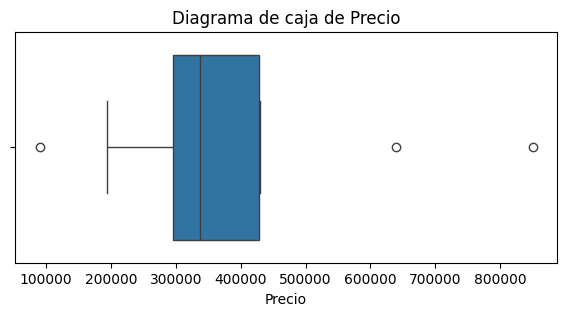

Índices outlier (boxplot): [1, 2, 9]
Utilidad: resume distribución, dispersión y posibles atípicos de manera visual.


In [4]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=dataset["Precio"])
plt.title("Diagrama de caja de Precio")
plt.show()
q1 = dataset["Precio"].quantile(0.25)
q3 = dataset["Precio"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
indices_outlier_box = dataset.index[(dataset["Precio"] < limite_inferior) | (dataset["Precio"] > limite_superior)]
print("Índices outlier (boxplot):", indices_outlier_box.tolist())
print("Utilidad: resume distribución, dispersión y posibles atípicos de manera visual.")


#### Mini desafío 2.B - Challenge

Use de diagrama de dispersión, para graficar la columna Precio adicionada al Dataframe y la columna Edad.

Muestre los Outlier en el gráfico e indique los índices. Cuáles son los valores del precio que se pueden considerar valores atípicos


¿Especifique la utilidad de un gráfico como el diagrama de dispersión para explorar los datos?


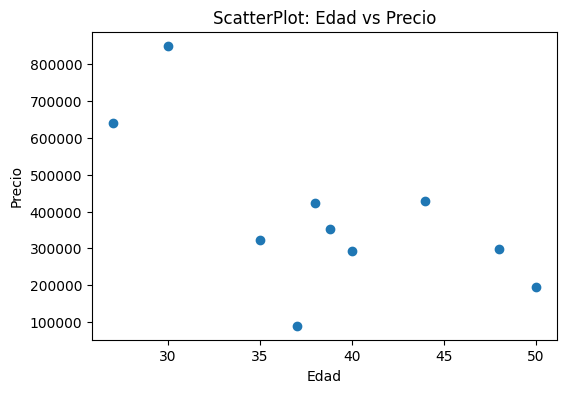

Índices outlier (scatter): [1, 2, 9]
Valores de precio atípicos: [639682.5, 850000.0, 90000.0]
Utilidad: permite ver relación entre variables y ubicar puntos extremos en el plano.


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(dataset["Edad"], dataset["Precio"])
ax.set_xlabel("Edad")
ax.set_ylabel("Precio")
ax.set_title("ScatterPlot: Edad vs Precio")
plt.show()
outliers_scatter = dataset[(dataset["Precio"] < limite_inferior) | (dataset["Precio"] > limite_superior)][["Edad", "Precio"]]
print("Índices outlier (scatter):", outliers_scatter.index.tolist())
print("Valores de precio atípicos:", outliers_scatter["Precio"].tolist())
print("Utilidad: permite ver relación entre variables y ubicar puntos extremos en el plano.")


#### Mini desafío 2.C - Challenge

Use los valores del rango intercuartílico para la columna Precio adicionada al Dataframe muestra los valores superiores y los valores inferiores siguiendo la fórmula con 1.5*IQR.  

¿Qué sucede al aumentar en 2 la fórmula del rango intercuartílico ? ¿Qué sucede al disminuir en la misma magnitud? ¿Qué nos dice sobre identificar los outlier?


In [6]:
def limites_iqr(columna, factor):
    q1_local = columna.quantile(0.25)
    q3_local = columna.quantile(0.75)
    iqr_local = q3_local - q1_local
    return q1_local - factor * iqr_local, q3_local + factor * iqr_local

li_15, ls_15 = limites_iqr(dataset["Precio"], 1.5)
li_35, ls_35 = limites_iqr(dataset["Precio"], 3.5)
li_05, ls_05 = limites_iqr(dataset["Precio"], 0.5)
outliers_15 = dataset[(dataset["Precio"] < li_15) | (dataset["Precio"] > ls_15)].index.tolist()
outliers_35 = dataset[(dataset["Precio"] < li_35) | (dataset["Precio"] > ls_35)].index.tolist()
outliers_05 = dataset[(dataset["Precio"] < li_05) | (dataset["Precio"] > ls_05)].index.tolist()
print("Límites con 1.5*IQR:", (li_15, ls_15))
print("Outliers con 1.5*IQR:", outliers_15)
print("Límites con 3.5*IQR:", (li_35, ls_35))
print("Outliers con 3.5*IQR:", outliers_35)
print("Límites con 0.5*IQR:", (li_05, ls_05))
print("Outliers con 0.5*IQR:", outliers_05)
print("Conclusión: al aumentar el factor se detectan menos atípicos; al disminuirlo se detectan más.")


Límites con 1.5*IQR: (np.float64(96961.0), np.float64(625813.0))
Outliers con 1.5*IQR: [1, 2, 9]
Límites con 3.5*IQR: (np.float64(-167465.0), np.float64(890239.0))
Outliers con 3.5*IQR: []
Límites con 0.5*IQR: (np.float64(229174.0), np.float64(493600.0))
Outliers con 0.5*IQR: [1, 2, 8, 9]
Conclusión: al aumentar el factor se detectan menos atípicos; al disminuirlo se detectan más.


#### Mini desafío 3 - Challenge

Ejecute sobre el atributo Precio.

Selecciona el registro que tiene una mayor diferencia con la media o es un valor atípico muy grande, sobre ese registro ejecute la acción de "**Eliminar el registro**"

Impute para dos registros restantes de los outliers del atributo Precio los valores de la media, de tal manera que no se elimina el registro, sólo se corrije o imputa el valor.


In [7]:
dataset_limpieza = dataset.copy()
media_precio = dataset_limpieza["Precio"].mean()
indice_eliminar = (dataset_limpieza["Precio"] - media_precio).abs().idxmax()
dataset_limpieza = dataset_limpieza.drop(index=indice_eliminar)
z_precios = np.abs(stats.zscore(dataset_limpieza["Precio"], nan_policy="omit"))
indices_outlier_z = dataset_limpieza.index[z_precios > 2].tolist()
if len(indices_outlier_z) < 2:
    q1_c = dataset_limpieza["Precio"].quantile(0.25)
    q3_c = dataset_limpieza["Precio"].quantile(0.75)
    iqr_c = q3_c - q1_c
    li_c = q1_c - 1.5 * iqr_c
    ls_c = q3_c + 1.5 * iqr_c
    indices_outlier_z = dataset_limpieza.index[(dataset_limpieza["Precio"] < li_c) | (dataset_limpieza["Precio"] > ls_c)].tolist()
indices_imputar = indices_outlier_z[:2]
media_sin_outliers = dataset_limpieza.loc[~dataset_limpieza.index.isin(indices_outlier_z), "Precio"].mean()
dataset_limpieza.loc[indices_imputar, "Precio"] = media_sin_outliers
print("Índice eliminado:", int(indice_eliminar))
print("Índices imputados:", indices_imputar)
print(dataset_limpieza[["No", "Precio"]])


Índice eliminado: 2
Índices imputados: [1, 9]
   No         Precio
0   1  429365.000000
1   2  330701.357143
3   4  421879.000000
4   5  294027.000000
5   6  323368.000000
6   7  352709.000000
7   8  299041.000000
8   9  194520.500000
9  10  330701.357143


#### Desafío 4 - Challenge

Realice la transformación de escalas directamente en el *Dataset* dado que algunos de los ejemplos mostrados están sobre otras copias del conjunto de datos.

Del dataset Transforme las variables categóricas con la codificación de en 0 y 1 (Compras)  Para la variable Tipo_Vivienda ejecute la variables Dummys similar al mostrado con la variable o atributo País en cuyo caso debe de igual manera ser actualizado en el *Dataset*.

Para las variables numéricas utilice ya sea la normalización o la estandarización según las fórmulas indicadas (Edad, Salario, Precio).

Guarde los datos limpios desde el dataset transformado y limpio, asegurese que el nombre sea: "Clean_Datos_Compras_XXX.csv", reemplace las X por su codigo

¿Qué conclusión puede extraer del proceso de preprocesamiento de datos y con cual de las fases del CRISP-DM se puede asociar?


In [9]:
dataset_base = dataset_limpieza if "dataset_limpieza" in globals() else dataset.copy()
dataset_transformado = dataset_base.copy()
dataset_transformado["Compra"] = dataset_transformado["Compra"].map({"No": 0, "Si": 1})
dataset_transformado = pd.get_dummies(dataset_transformado, columns=["Tipo_Vivienda"], dtype=int)
escalador = StandardScaler()
dataset_transformado[["Edad", "Salario", "Precio"]] = escalador.fit_transform(dataset_transformado[["Edad", "Salario", "Precio"]])
ruta_salida = "Datos_Compras_limpios_160004613.csv"
dataset_transformado.to_csv(ruta_salida, index=False)
print(dataset_transformado.head())
print("Archivo guardado:", ruta_salida)
print("Conclusión: el preprocesamiento mejora la calidad y comparabilidad de los datos, y se asocia a la fase de Preparación de Datos en CRISP-DM.")


   No      País      Edad   Salario  Compra    Precio  \
0   1   Francia  0.646859  0.646243       0  1.489696   
1   2    España -1.942457 -1.527280       1  0.000000   
3   4    España -0.267017 -0.349955       0  1.376666   
4   5  Alemania  0.037608 -0.098390       1 -0.553736   
5   6   Francia -0.723955 -0.621646       1 -0.110724   

   Tipo_Vivienda_Apartamento  Tipo_Vivienda_Casa  
0                          0                   1  
1                          1                   0  
3                          1                   0  
4                          0                   1  
5                          0                   1  
Archivo guardado: Datos_Compras_limpios_160004613.csv
Conclusión: el preprocesamiento mejora la calidad y comparabilidad de los datos, y se asocia a la fase de Preparación de Datos en CRISP-DM.
